In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

sns.set_theme(style="white", font="sans-serif")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Arial"]

In [5]:
plan_plot_data = {
    'Pangu-NLP-N2-128K': [11.2, 9.8, 9.8, 11.4, 10.4, 14.4, 11.4, 9.8, 15.0, 10.2],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [16.4, 20.4, 18.2, 12.8, 16.0, 16.4, 16.6, 11.4, 12.6, 12.0],
    'Pangu-NLP-N2-Reasoner-128K': [13.2, 10.6, 15.0, 9.6, 12.2, 10.2, 17.2, 12.6, 17.2, 13.0],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [19.0, 19.0, 20.0, 17.2, 17.8, 18.2, 19.4, 15.4, 19.2, 17.2],
    'Phyto-ChatBot': [15.0, 19.6, 15.6, 11.8, 12.4, 16.6, 16.6, 16.6, 17.0, 17.0],
    'Phyto-ChatBot (Knowledge Agent)': [17.8, 20.4, 18.2, 18.2, 16.6, 17.8, 16.8, 17.8, 20.0, 19.8],
    'Phyto-Reasoner': [15.8, 18.8, 17.6, 18.2, 14.4, 13.2, 17.6, 17.0, 17.8, 17.0],
    'Phyto-Reasoner (Knowledge Agent)': [17.0, 19.6, 18.4, 18.0, 20.6, 18.2, 19.0, 22.4, 22.0, 20.8],
    'GPT-5': [19.4, 18.6, 18.8, 19.8, 20.2, 18.4, 19.2, 17.2, 20.4, 20.6],
    'o3': [19.6, 18.6, 17.4, 19.8, 18.6, 19.2, 19.4, 15.0, 22.0, 19.0],
    'Gemini-2.5-Pro': [19.4, 18.2, 16.8, 17.8, 19.0, 17.8, 19.4, 12.2, 21.0, 21.6],
    'Claude-Opus-4.1': [20.6, 20.0, 20.4, 17.4, 20.8, 19.6, 19.2, 20.0, 23.4, 22.0],
    'Grok-3-Beta': [17.8, 18.8, 18.4, 15.0, 16.0, 14.8, 16.6, 15.0, 18.0, 18.0],
    'DeepSeek-V3': [18.0, 19.4, 19.2, 17.4, 16.2, 16.8, 16.6, 14.2, 22.0, 20.8],
    'DeepSeek-R1': [17.4, 18.2, 15.8, 18.2, 18.4, 19.0, 17.6, 13.4, 21.0, 20.0],
}
tool_plot_data = {
    'Pangu-NLP-N2-128K': [7.0, 5.8, 7.6, 8.4, 10.8, 12.4, 11.2, 10.6, 12.0, 10.2],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [13.8, 19.6, 17.0, 10.8, 16.0, 16.4, 15.0, 11.8, 11.8, 11.0],
    'Pangu-NLP-N2-Reasoner-128K': [9.6, 7.6, 13.0, 7.8, 11.2, 8.8, 15.6, 13.6, 18.0, 12.0],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [18.2, 20.0, 19.8, 15.8, 17.8, 18.0, 18.2, 14.2, 17.4, 16.0],
    'Phyto-ChatBot': [17.2, 19.6, 14.6, 12.2, 12.8, 16.6, 15.6, 15.8, 15.0, 16.0],
    'Phyto-ChatBot (Knowledge Agent)': [16.6, 20.8, 17.0, 17.8, 16.4, 15.4, 16.8, 18.0, 19.0, 18.8],
    'Phyto-Reasoner': [15.2, 19.4, 16.6, 17.0, 13.8, 13.0, 17.6, 16.0, 16.8, 16.0],
    'Phyto-Reasoner (Knowledge Agent)': [17.0, 19.8, 18.0, 18.4, 21.0, 18.2, 18.6, 21.0, 22.0, 19.8],
    'GPT-5': [18.6, 18.4, 19.2, 18.2, 20.6, 18.6, 19.2, 17.0, 20.0, 20.8],
    'o3': [17.8, 17.8, 16.2, 19.6, 17.8, 18.8, 18.4, 13.4, 21.0, 18.0],
    'Gemini-2.5-Pro': [15.8, 18.2, 16.6, 18.8, 19.0, 17.8, 18.4, 12.8, 20.0, 20.6],
    'Claude-Opus-4.1': [21.2, 20.0, 18.8, 19.2, 20.4, 20.4, 19.4, 19.8, 23.2, 22.0],
    'Grok-3-Beta': [17.6, 18.8, 19.2, 14.0, 16.0, 14.8, 15.6, 13.4, 18.0, 17.0],
    'DeepSeek-V3': [17.8, 19.6, 18.8, 16.4, 16.2, 16.8, 15.6, 14.0, 22.0, 19.8],
    'DeepSeek-R1': [18.4, 18.4, 12.2, 18.0, 18.2, 19.4, 16.6, 13.0, 20.0, 19.0],
}
param_plot_data = {
    'Pangu-NLP-N2-128K': [8.6, 5.6, 8.0, 9.4, 10.6, 11.4, 8.0, 10.2, 11.0, 11.2],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [17.8, 16.8, 16.0, 13.2, 14.6, 13.8, 12.8, 14.2, 14.4, 14.2],
    'Pangu-NLP-N2-Reasoner-128K': [8.6, 7.4, 12.4, 6.6, 10.0, 9.4, 13.4, 12.0, 16.8, 14.0],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [17.8, 19.2, 16.0, 14.2, 14.2, 15.2, 15.4, 14.6, 21.0, 16.6],
    'Phyto-ChatBot': [13.2, 14.8, 12.4, 11.4, 14.4, 12.6, 13.0, 15.6, 14.0, 14.0],
    'Phyto-ChatBot (Knowledge Agent)': [21.8, 20.2, 20.0, 17.0, 17.0, 14.6, 13.4, 15.8, 17.0, 18.6],
    'Phyto-Reasoner': [15.4, 15.0, 15.4, 14.4, 13.6, 13.2, 14.2, 16.2, 15.0, 15.0],
    'Phyto-Reasoner (Knowledge Agent)': [23.4, 22.0, 21.6, 21.6, 21.0, 18.2, 21.6, 18.4, 19.0, 21.2],
    'GPT-5': [15.2, 23.2, 18.0, 18.4, 19.4, 21.0, 18.8, 15.0, 21.8, 19.0],
    'o3': [16.4, 14.8, 14.6, 16.6, 14.6, 16.4, 15.4, 13.4, 18.8, 18.0],
    'Gemini-2.5-Pro': [16.6, 13.8, 14.0, 16.0, 16.4, 15.4, 17.8, 15.0, 18.0, 19.0],
    'Claude-Opus-4.1': [17.6, 18.0, 18.4, 17.6, 18.6, 18.8, 18.8, 17.6, 20.2, 20.0],
    'Grok-3-Beta': [14.4, 15.2, 14.8, 12.2, 22.4, 13.0, 13.4, 11.8, 15.0, 15.0],
    'DeepSeek-V3': [13.2, 15.6, 15.6, 13.0, 13.6, 13.8, 12.8, 13.6, 19.0, 18.8],
    'DeepSeek-R1': [10.6, 13.6, 11.8, 14.6, 14.2, 17.0, 13.6, 11.8, 18.0, 19.0],
}
rate_plot_data = {
    'Pangu-NLP-N2-128K': [6.0, 6.0, 6.25, 6.25, 16.75, 9.25, 7.0, 6.25, 6.0, 6.25],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [7.5, 8.75, 7.5, 8.5, 17.5, 11.0, 7.0, 5.25, 6.0, 8.0],
    'Pangu-NLP-N2-Reasoner-128K': [6.25, 7.5, 8.75, 7.75, 17.5, 15.0, 7.5, 6.25, 6.25, 7.5],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [7.0, 7.5, 8.75, 8.75, 18.75, 10.75, 8.75, 7.25, 7.5, 9.25],
    'Phyto-ChatBot': [6.25, 7.5, 8.75, 9.5, 16.75, 10.0, 8.5, 5.75, 6.75, 7.25],
    'Phyto-ChatBot (Knowledge Agent)': [7.5, 8.75, 15.0, 9.75, 20.0, 9.0, 11.25, 5.25, 7.5, 10.0],
    'Phyto-Reasoner': [7.916666666666666, 8.75, 8.75, 10.5, 18.75, 16.0, 9.75, 7.5, 7.25, 7.5],
    'Phyto-Reasoner (Knowledge Agent)': [10.0, 10.0, 16.25, 10.75, 21.25, 11.5, 15.0, 8.75, 8.0, 10.0],
    'GPT-5': [7.5, 11.0, 9.75, 9.75, 17.75, 18.25, 8.5, 6.75, 11.5, 8.5],
    'o3': [9.75, 8.5, 7.5, 5.25, 15.25, 5.75, 9.75, 5.75, 5.75, 6.25],
    'Gemini-2.5-Pro': [7.0, 8.75, 10.0, 8.0, 11.25, 11.25, 12.0, 7.5, 6.0, 8.916666666666666],
    'Claude-Opus-4.1': [7.5, 8.75, 10.0, 8.5, 20.25, 17.0, 11.25, 6.25, 7.5, 7.5],
    'Grok-3-Beta': [9.5, 10.0, 6.25, 8.75, 23.75, 15.0, 8.75, 6.25, 9.75, 6.0],
    'DeepSeek-V3': [6.0, 6.25, 7.5, 8.25, 18.75, 15.83333333333334, 7.5, 7.5, 5.25, 6.0],
    'DeepSeek-R1': [5.5, 10.0, 8.75, 8.75, 16.75, 12.25, 9.5, 8.75, 11.0, 7.5],
}
columns_all = [
    'Transcriptome', 'Proteomics', 'Metabolome', 'Evolution', 'Epicgenetic',
    'Genome-CallSNP', 'Genome-GWAS', 'Genome-GS', 'SingleCell', 'Spatial'
]
plot_plan_df = pd.DataFrame(plan_plot_data).T
plot_plan_df.columns = columns_all
plot_tool_df = pd.DataFrame(tool_plot_data).T
plot_tool_df.columns = columns_all
plot_param_df = pd.DataFrame(param_plot_data).T
plot_param_df.columns = columns_all
plot_rate_df = pd.DataFrame(rate_plot_data).T
plot_rate_df.columns = columns_all

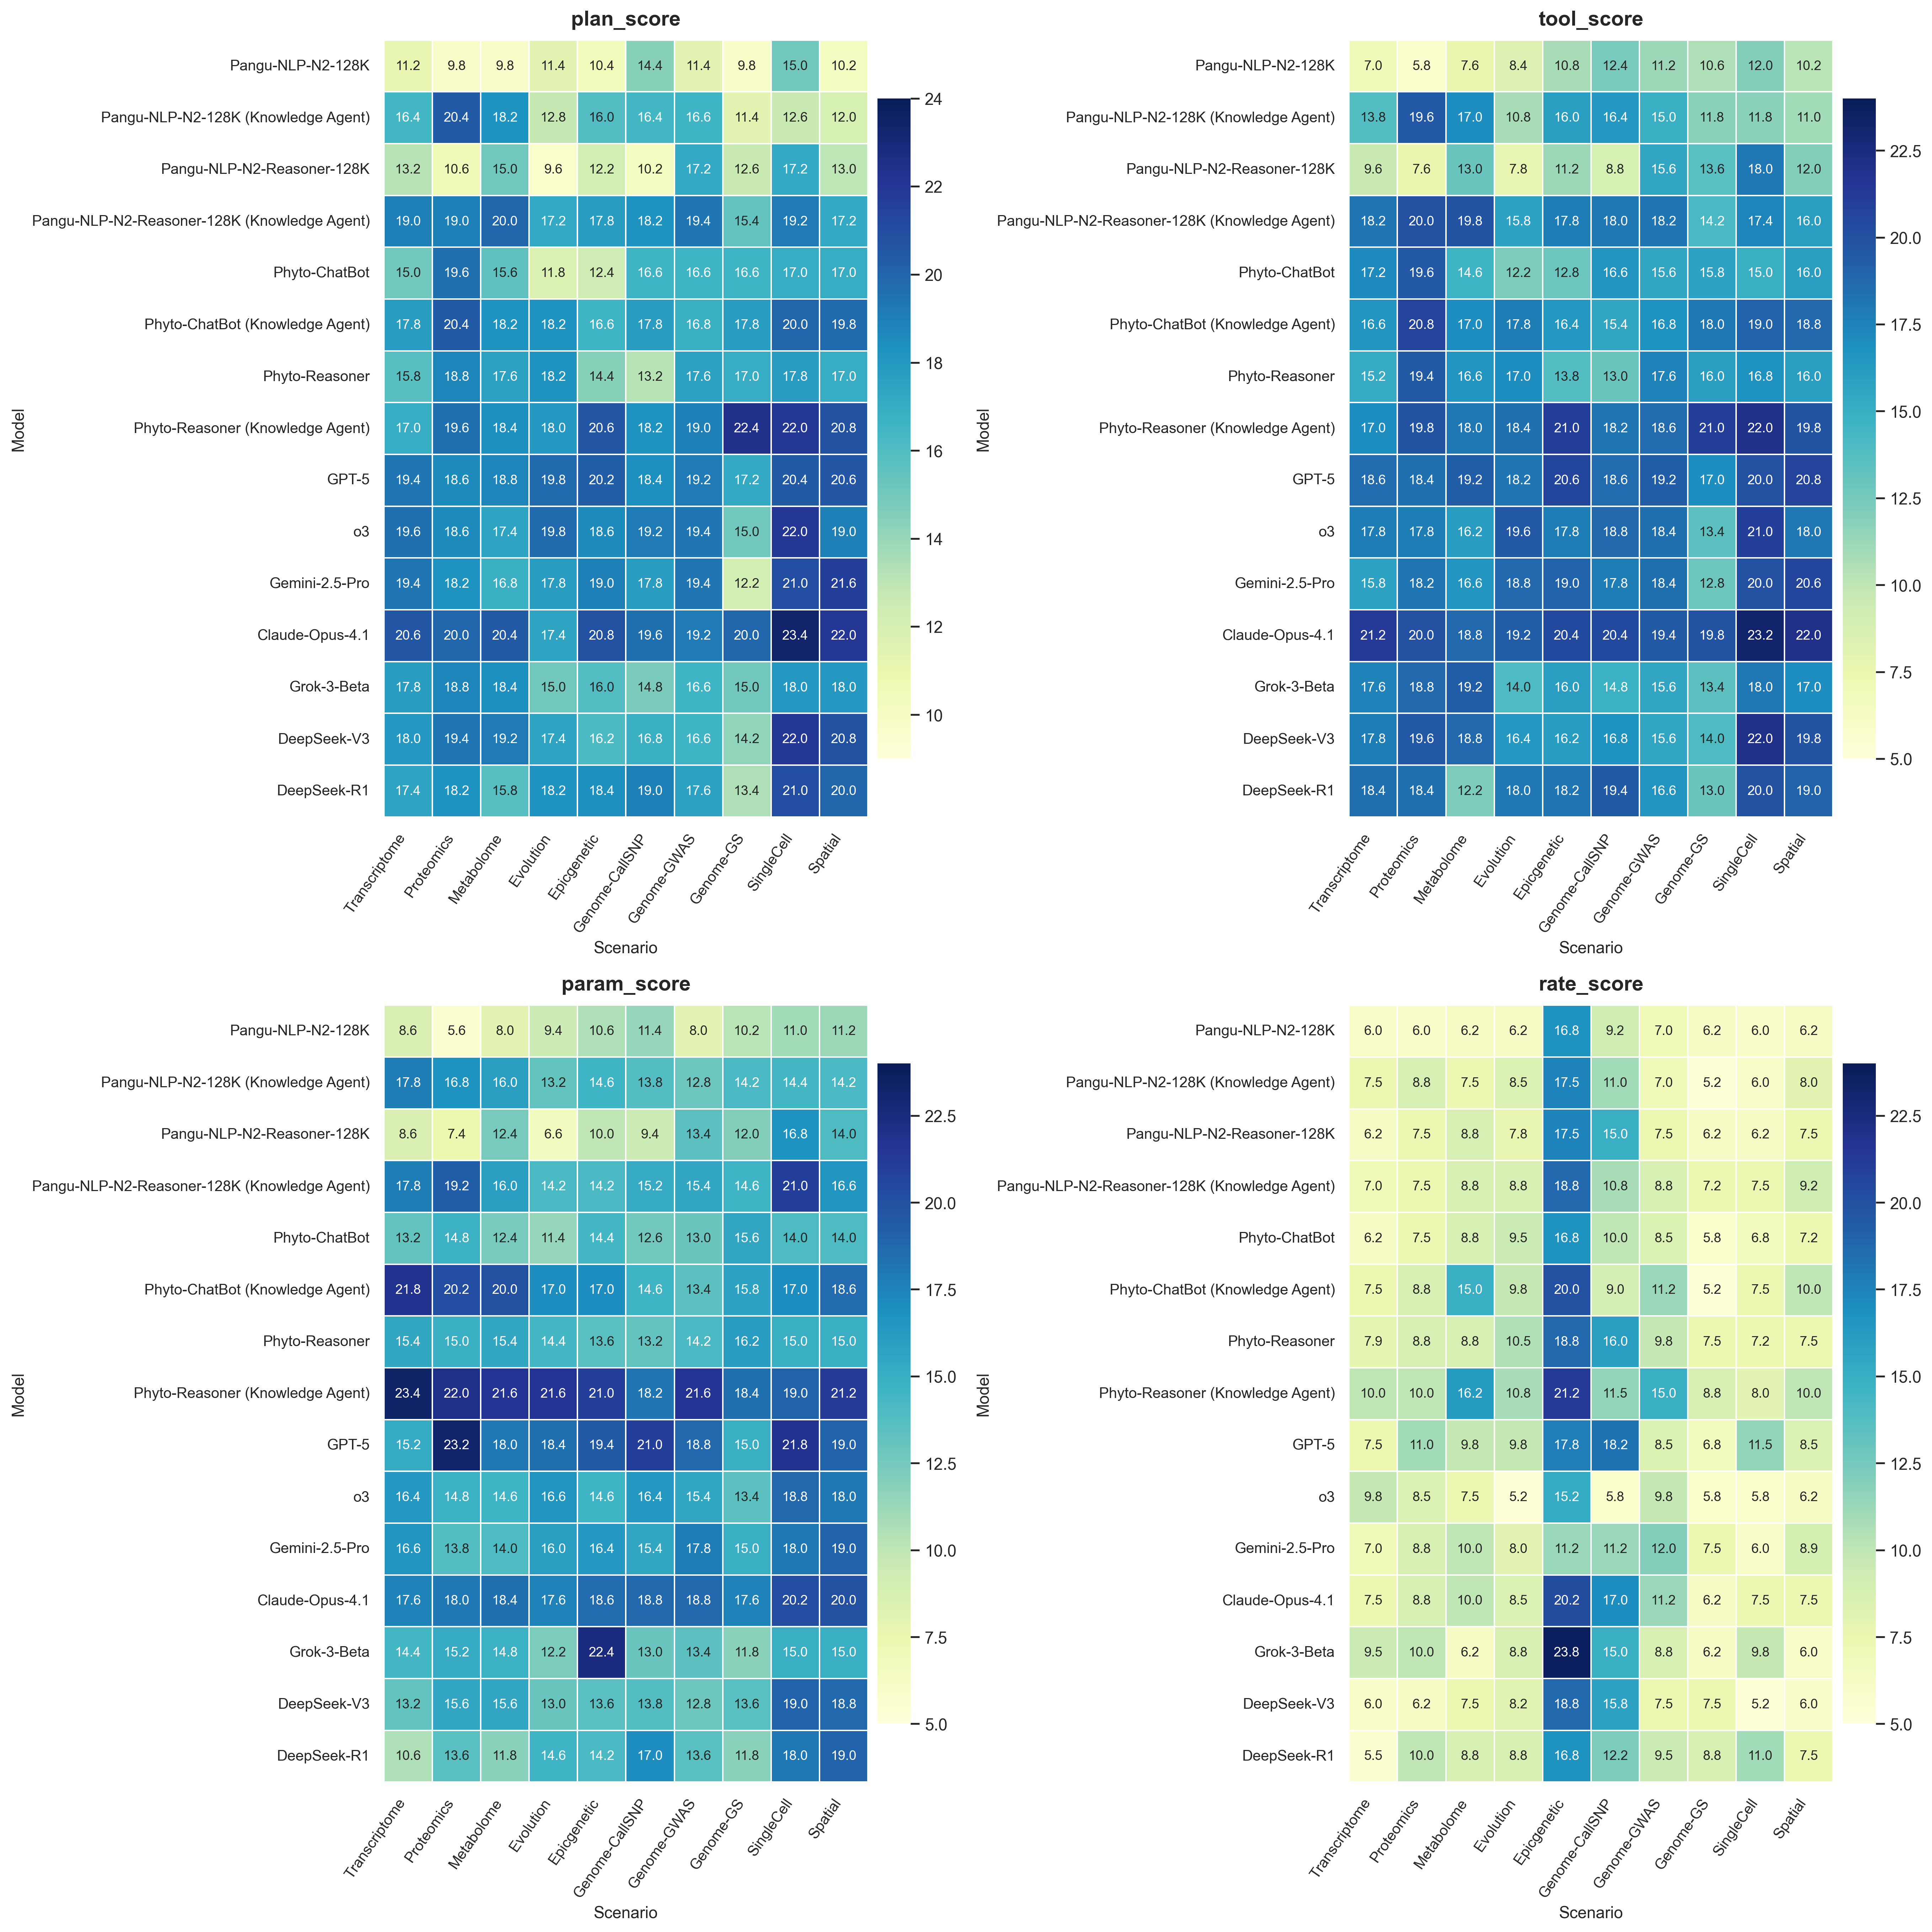

In [ ]:
metrics = {
    "plan_score": plot_plan_df,
    "tool_score": plot_tool_df,
    "param_score": plot_param_df,
    "rate_score": plot_rate_df
}

scenario_order = [
    'Transcriptome', 'Proteomics', 'Metabolome', 'Evolution', 'Epicgenetic',
    'Genome-CallSNP', 'Genome-GWAS', 'Genome-GS', 'SingleCell', 'Spatial'
]
model_order = [
    'Pangu-NLP-N2-128K', 'Pangu-NLP-N2-128K (Knowledge Agent)', 'Pangu-NLP-N2-Reasoner-128K', 'Pangu-NLP-N2-Reasoner-128K (Konwledge Agent)', 
    'Phyto-ChatBot', 'Phyto-ChatBot (Konwledge Agent)', 'Phyto-Reasoner', 'Phyto-Reasoner (Knowledge Agent)', 
    'GPT-5', 'o3', 'Gemini-2.5-Pro', 'Claude-Opus-4.1', 'Grok-3-Beta', 'DeepSeek-V3', 'DeepSeek-R1'
]

def get_nice_range(values, step=1):
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    vmin = math.floor(vmin / step) * step
    vmax = math.ceil(vmax / step) * step
    if vmin == vmax:
        vmax = vmin + step
    return vmin, vmax


fig, axes = plt.subplots(2, 2, figsize=(18, 18), constrained_layout=True, dpi=300)
axes = axes.flatten()
for ax, (title, pivot_df) in zip(axes, metrics.items()):
    vmin, vmax = get_nice_range(pivot_df.values, step=1)

    hm = sns.heatmap(
        pivot_df,
        ax=ax,
        cmap="YlGnBu",
        annot=True,
        fmt=".1f",
        annot_kws={"size": 9},
        linewidths=0.5,
        linecolor="white",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={"shrink": 0.85, "pad": 0.02}
    )

    ax.set_title(title, fontsize=14, weight="bold", pad=10)
    ax.set_xlabel("Scenario", fontsize=11)
    ax.set_ylabel("Model", fontsize=11)

    ax.tick_params(axis="x", labelrotation=55, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

# plt.savefig('./model_compare_agent_split.pdf')
plt.show()